In [1]:
%pip install -q -U google-genai

Note: you may need to restart the kernel to use updated packages.


In [2]:
from google import genai

print("=" * 70)
print("GEMINI SDK CHECK")
print("=" * 70)

print("\nGemini SDK import: SUCCESS ✓")
print("google-genai is ready.")
print("\nNo API call made.")

GEMINI SDK CHECK

Gemini SDK import: SUCCESS ✓
google-genai is ready.

No API call made.


In [3]:
import os

api_key = os.getenv("GEMINI_API_KEY")

print("=" * 70)
print("GEMINI API KEY CHECK")
print("=" * 70)

if api_key:
    print("\nGEMINI_API_KEY: FOUND ✓")
    print("Key length:", len(api_key))
    print("Key value is NOT displayed.")
else:
    print("\nGEMINI_API_KEY: NOT FOUND")
    print("No API call made.")

GEMINI API KEY CHECK

GEMINI_API_KEY: FOUND ✓
Key length: 53
Key value is NOT displayed.


In [4]:
import os

api_key = os.getenv("GEMINI_API_KEY")

print("=" * 70)
print("GEMINI API KEY CHECK")
print("=" * 70)

if api_key:
    print("\nGEMINI_API_KEY: FOUND ✓")
    print("Key length:", len(api_key))
    print("Key value is NOT displayed.")
    print("\nNo API call made.")
else:
    print("\nGEMINI_API_KEY: NOT FOUND")
    print("No API call made.")

GEMINI API KEY CHECK

GEMINI_API_KEY: FOUND ✓
Key length: 53
Key value is NOT displayed.

No API call made.


In [7]:
from google import genai

client = genai.Client()

MODEL_NAME = "gemini-3.1-flash-lite"

response = client.models.generate_content(
    model=MODEL_NAME,
    contents="Reply with exactly: GEMINI_OK"
)

print("=" * 70)
print("GEMINI FREE-TIER MODEL TEST")
print("=" * 70)

print(f"\nModel: {MODEL_NAME}")
print(f"Response: {response.text}")

print("\nAPI test: SUCCESS ✓")

GEMINI FREE-TIER MODEL TEST

Model: gemini-3.1-flash-lite
Response: GEMINI_OK

API test: SUCCESS ✓


In [6]:
from google import genai

client = genai.Client()

print("=" * 70)
print("AVAILABLE GEMINI MODELS")
print("=" * 70)

models = list(client.models.list())

for model in models:
    name = getattr(model, "name", "")
    methods = getattr(model, "supported_actions", None)

    if "generateContent" in str(methods) or "generate_content" in str(methods):
        print(f"\nModel   : {name}")
        print(f"Methods : {methods}")

AVAILABLE GEMINI MODELS

Model   : models/gemini-2.5-flash
Methods : ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']

Model   : models/gemini-2.5-pro
Methods : ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']

Model   : models/gemini-2.5-flash-preview-tts
Methods : ['countTokens', 'generateContent']

Model   : models/gemini-2.5-pro-preview-tts
Methods : ['countTokens', 'generateContent', 'batchGenerateContent']

Model   : models/gemma-4-26b-a4b-it
Methods : ['generateContent', 'countTokens']

Model   : models/gemma-4-31b-it
Methods : ['generateContent', 'countTokens']

Model   : models/gemini-flash-latest
Methods : ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']

Model   : models/gemini-flash-lite-latest
Methods : ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']

Model   : models/gemini-pro-latest
Methods : ['generateContent', 'countTokens', 'createCache

In [8]:
from pydantic import BaseModel
from typing import List


class Prediction(BaseModel):
    finding: str
    probability: float


class VisualExplanation(BaseModel):
    finding: str
    description: str
    gradcam_note: str


class MedicalContext(BaseModel):
    finding: str
    summary: str
    evidence_status: str


class Interpretation(BaseModel):
    summary: str
    confidence_note: str


class Citation(BaseModel):
    chunk_id: str
    title: str


class GeminiRAGResponse(BaseModel):
    predictions: List[Prediction]
    visual_explanation: VisualExplanation
    medical_context: MedicalContext
    interpretation: Interpretation
    limitations: List[str]
    citations: List[Citation]


print("=" * 70)
print("GEMINI STRUCTURED RESPONSE SCHEMA")
print("=" * 70)

print("\nSchema created successfully ✓")
print("\nTop-level fields:")

for field in GeminiRAGResponse.model_fields:
    print(f"  ✓ {field}")

GEMINI STRUCTURED RESPONSE SCHEMA

Schema created successfully ✓

Top-level fields:
  ✓ predictions
  ✓ visual_explanation
  ✓ medical_context
  ✓ interpretation
  ✓ limitations
  ✓ citations


In [10]:
from google.genai import types

gemini_config = types.GenerateContentConfig(
    response_mime_type="application/json",
    response_schema=GeminiRAGResponse,
    temperature=0.2,
    max_output_tokens=500
)

print("=" * 70)
print("GEMINI STRUCTURED OUTPUT CONFIGURATION")
print("=" * 70)

print("\nResponse format : JSON ✓")
print("Schema          : GeminiRAGResponse ✓")
print("Temperature     : 0.2")
print("Max output      : 500 tokens")
print("\nConfiguration ready ✓")

GEMINI STRUCTURED OUTPUT CONFIGURATION

Response format : JSON ✓
Schema          : GeminiRAGResponse ✓
Temperature     : 0.2
Max output      : 500 tokens

Configuration ready ✓


In [11]:
from pydantic import BaseModel
from typing import List


class VisualExplanation(BaseModel):
    description: str
    gradcam_note: str


class MedicalContext(BaseModel):
    summary: str
    evidence_status: str


class Interpretation(BaseModel):
    summary: str
    confidence_note: str


class Citation(BaseModel):
    chunk_id: str
    title: str


class GeminiInterpretation(BaseModel):
    visual_explanation: VisualExplanation
    medical_context: MedicalContext
    interpretation: Interpretation
    limitations: List[str]
    citations: List[Citation]


print("=" * 70)
print("OPTIMIZED GEMINI RESPONSE SCHEMA")
print("=" * 70)

print("\nGemini-generated fields:")

for field in GeminiInterpretation.model_fields:
    print(f"  ✓ {field}")

print("\nCNN prediction will be supplied by Python ✓")
print("Gemini cannot modify the CNN probability ✓")
print("Citation URLs will be resolved by Python ✓")

OPTIMIZED GEMINI RESPONSE SCHEMA

Gemini-generated fields:
  ✓ visual_explanation
  ✓ medical_context
  ✓ interpretation
  ✓ limitations
  ✓ citations

CNN prediction will be supplied by Python ✓
Gemini cannot modify the CNN probability ✓
Citation URLs will be resolved by Python ✓


In [12]:
def build_compact_gemini_prompt(
    finding,
    probability,
    gradcam_description,
    evidence_status,
    primary_evidence,
    general_evidence
):
    evidence_blocks = []

    for item in primary_evidence:
        evidence_blocks.append(
            f"[{item['chunk_id']}] {item['title']}\n"
            f"{item['text']}"
        )

    for item in general_evidence:
        evidence_blocks.append(
            f"[{item['chunk_id']}] {item['title']}\n"
            f"{item['text']}"
        )

    evidence_text = "\n\n".join(evidence_blocks)

    prompt = f"""
You are the evidence-synthesis layer of a medical AI research application.

Prediction:
Finding: {finding}
Probability: {probability:.4f}

Visual attribution:
{gradcam_description}

Evidence status: {evidence_status}

Evidence:
{evidence_text}

Instructions:
- Use only the supplied evidence.
- Do not invent medical facts.
- Do not diagnose the patient.
- Model probability is not clinical certainty.
- Grad-CAM is attribution, not diagnostic proof.
- Treat ChestX-ray14 labels as research labels.
- Use only supplied chunk IDs for citations.
- Keep the response concise.
"""

    return prompt


print("=" * 70)
print("COMPACT GEMINI PROMPT BUILDER")
print("=" * 70)

print("\nPrompt builder created successfully ✓")
print("Only primary + general RAG evidence will be sent ✓")
print("Secondary evidence excluded ✓")
print("CNN probability remains controlled by Python ✓")
print("No API call made ✓")

COMPACT GEMINI PROMPT BUILDER

Prompt builder created successfully ✓
Only primary + general RAG evidence will be sent ✓
Secondary evidence excluded ✓
CNN probability remains controlled by Python ✓
No API call made ✓


In [13]:
# Small test case using the previously validated Pneumothorax RAG evidence

test_finding = "Pneumothorax"
test_probability = 0.87

test_gradcam_description = (
    "Grad-CAM highlights image regions that contributed to the model prediction. "
    "These regions are model-attributed and do not establish a diagnosis."
)

test_primary_evidence = [
    {
        "chunk_id": "pneumothorax_001",
        "title": "Diseases of the Pleura and Chest Wall",
        "text": (
            "Good quality upright radiographs are sensitive for identifying a "
            "pneumothorax. Air outside the pleura moves to a nondependent location "
            "in the apex, which separates the pleura from the chest wall. The "
            "intervening air is radiolucent, resulting in a visible pleural line. "
            "Beyond the pleural line there should be no vessels or lung parenchymal "
            "markings visible."
        )
    }
]

test_general_evidence = [
    {
        "chunk_id": "chest_xray_general_001",
        "title": "Chest X-ray",
        "text": (
            "Chest X-rays use a small amount of ionizing radiation to produce "
            "images of the lungs, heart, and chest wall. They can help evaluate "
            "symptoms and a range of conditions, but a normal chest X-ray does "
            "not rule out every abnormality."
        )
    }
]

test_evidence_status = "SUFFICIENT"

print("=" * 70)
print("RAG → GEMINI TEST CONTEXT")
print("=" * 70)

print(f"\nFinding       : {test_finding}")
print(f"Probability   : {test_probability}")
print(f"Evidence      : {test_evidence_status}")
print(f"Primary       : {len(test_primary_evidence)} chunk")
print(f"General       : {len(test_general_evidence)} chunk")

RAG → GEMINI TEST CONTEXT

Finding       : Pneumothorax
Probability   : 0.87
Evidence      : SUFFICIENT
Primary       : 1 chunk
General       : 1 chunk


In [14]:
test_prompt = build_compact_gemini_prompt(
    finding=test_finding,
    probability=test_probability,
    gradcam_description=test_gradcam_description,
    evidence_status=test_evidence_status,
    primary_evidence=test_primary_evidence,
    general_evidence=test_general_evidence
)

print("=" * 70)
print("GEMINI PROMPT PREVIEW")
print("=" * 70)

print(test_prompt)

print("\n" + "=" * 70)
print(f"Approximate prompt characters: {len(test_prompt):,}")
print(f"Approximate input tokens:      {len(test_prompt) // 4:,}")
print("=" * 70)

GEMINI PROMPT PREVIEW

You are the evidence-synthesis layer of a medical AI research application.

Prediction:
Finding: Pneumothorax
Probability: 0.8700

Visual attribution:
Grad-CAM highlights image regions that contributed to the model prediction. These regions are model-attributed and do not establish a diagnosis.

Evidence status: SUFFICIENT

Evidence:
[pneumothorax_001] Diseases of the Pleura and Chest Wall
Good quality upright radiographs are sensitive for identifying a pneumothorax. Air outside the pleura moves to a nondependent location in the apex, which separates the pleura from the chest wall. The intervening air is radiolucent, resulting in a visible pleural line. Beyond the pleural line there should be no vessels or lung parenchymal markings visible.

[chest_xray_general_001] Chest X-ray
Chest X-rays use a small amount of ionizing radiation to produce images of the lungs, heart, and chest wall. They can help evaluate symptoms and a range of conditions, but a normal chest X

In [15]:
response = client.models.generate_content(
    model=MODEL_NAME,
    contents=test_prompt,
    config=gemini_config
)

print("=" * 70)
print("FIRST GEMINI RAG GENERATION")
print("=" * 70)

print("\nResponse received ✓")
print("\nStructured response:")
print(response.text)

ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [16]:
model_info = client.models.get(model=MODEL_NAME)

print("=" * 70)
print("SELECTED GEMINI MODEL")
print("=" * 70)

print(f"\nModel name : {model_info.name}")
print(f"Display    : {model_info.display_name}")

print("\nModel information retrieved ✓")

SELECTED GEMINI MODEL

Model name : models/gemini-3.1-flash-lite
Display    : Gemini 3.1 Flash Lite

Model information retrieved ✓


In [17]:
try:
    response = client.models.generate_content(
        model=MODEL_NAME,
        contents="Reply with exactly: OK",
        config=types.GenerateContentConfig(
            max_output_tokens=5
        )
    )

    print("=" * 70)
    print("MINIMAL GEMINI AVAILABILITY TEST")
    print("=" * 70)
    print("\nResponse:", response.text)
    print("\nModel generation: AVAILABLE ✓")

except Exception as e:
    print("=" * 70)
    print("MINIMAL GEMINI AVAILABILITY TEST")
    print("=" * 70)
    print("\nGeneration failed.")
    print("\nError:", e)

MINIMAL GEMINI AVAILABILITY TEST

Response: OK

Model generation: AVAILABLE ✓


In [18]:
structured_test_prompt = """
Return a concise interpretation for this research-model prediction.

Finding: Pneumothorax
Probability: 0.87

Use the supplied information only.
Do not diagnose the patient.
The probability is a model output, not clinical certainty.
"""

structured_response = client.models.generate_content(
    model=MODEL_NAME,
    contents=structured_test_prompt,
    config=gemini_config
)

print("=" * 70)
print("STRUCTURED OUTPUT TEST")
print("=" * 70)

print("\nResponse received ✓")
print("\nRaw JSON response:")
print(structured_response.text)

ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [19]:
gemini_config = types.GenerateContentConfig(
    temperature=0.2,
    max_output_tokens=500
)

print("=" * 70)
print("GEMINI PLAIN JSON CONFIGURATION")
print("=" * 70)

print("\nNative response schema : DISABLED ✓")
print("Native JSON MIME type  : DISABLED ✓")
print("Temperature             : 0.2")
print("Max output tokens      : 500")
print("\nGemini will return JSON text.")
print("Python/Pydantic will validate it locally ✓")

GEMINI PLAIN JSON CONFIGURATION

Native response schema : DISABLED ✓
Native JSON MIME type  : DISABLED ✓
Temperature             : 0.2
Max output tokens      : 500

Gemini will return JSON text.
Python/Pydantic will validate it locally ✓


In [20]:
gemini_config = types.GenerateContentConfig(
    temperature=0.2,
    max_output_tokens=500
)

print("=" * 70)
print("GEMINI PLAIN JSON CONFIGURATION")
print("=" * 70)

print("\nNative response schema : DISABLED ✓")
print("Native JSON MIME type  : DISABLED ✓")
print("Temperature             : 0.2")
print("Max output tokens      : 500")
print("\nGemini will return JSON text.")
print("Python/Pydantic will validate it locally ✓")

GEMINI PLAIN JSON CONFIGURATION

Native response schema : DISABLED ✓
Native JSON MIME type  : DISABLED ✓
Temperature             : 0.2
Max output tokens      : 500

Gemini will return JSON text.
Python/Pydantic will validate it locally ✓


In [21]:
plain_json_prompt = """
Return ONLY valid JSON.

Use this exact structure:
{
  "visual_explanation": {
    "description": "brief description",
    "gradcam_note": "brief note"
  },
  "medical_context": {
    "summary": "brief evidence-based summary",
    "evidence_status": "SUFFICIENT"
  },
  "interpretation": {
    "summary": "brief interpretation",
    "confidence_note": "brief confidence note"
  },
  "limitations": [
    "limitation 1"
  ],
  "citations": [
    {
      "chunk_id": "pneumothorax_001",
      "title": "Diseases of the Pleura and Chest Wall"
    }
  ]
}

Rules:
- Finding: Pneumothorax
- Model probability: 0.87
- Use only the supplied evidence conceptually.
- Do not diagnose the patient.
- Do not change or reinterpret the probability.
- Do not invent citation IDs.
"""

plain_response = client.models.generate_content(
    model=MODEL_NAME,
    contents=plain_json_prompt,
    config=gemini_config
)

print("=" * 70)
print("PLAIN JSON GEMINI TEST")
print("=" * 70)

print("\nResponse received ✓")
print("\nRaw response:")
print(plain_response.text)

PLAIN JSON GEMINI TEST

Response received ✓

Raw response:
{
  "visual_explanation": {
    "description": "The model highlights the peripheral lung field, identifying a lack of vascular markings and a visible pleural line.",
    "gradcam_note": "Activation maps are concentrated along the lateral chest wall, consistent with the location of a potential pneumothorax."
  },
  "medical_context": {
    "summary": "A pneumothorax is characterized by the presence of air in the pleural space, leading to lung collapse and the absence of peripheral lung markings on imaging.",
    "evidence_status": "SUFFICIENT"
  },
  "interpretation": {
    "summary": "The model indicates a 0.87 probability of pneumothorax based on the radiographic features identified.",
    "confidence_note": "The high probability score reflects strong alignment between the visual features and the model's training data for pneumothorax."
  },
  "limitations": [
    "Radiographic findings can be mimicked by skin folds or bullous

In [22]:
import json

try:
    parsed_response = json.loads(plain_response.text)
    validated_response = GeminiInterpretation.model_validate(parsed_response)

    print("=" * 70)
    print("LOCAL GEMINI RESPONSE VALIDATION")
    print("=" * 70)

    print("\nJSON parsing      : PASS ✓")
    print("Pydantic schema   : PASS ✓")

except json.JSONDecodeError as e:
    print("JSON parsing      : FAILED ✗")
    print("Error:", e)

except Exception as e:
    print("Pydantic schema   : FAILED ✗")
    print("Error:", e)

LOCAL GEMINI RESPONSE VALIDATION

JSON parsing      : PASS ✓
Pydantic schema   : PASS ✓


In [23]:
def validate_grounding(response, rag_context):
    """
    Conservative grounding check.

    Checks whether cited chunk IDs actually exist in the supplied
    primary/general evidence and whether the response has citations.
    It does NOT claim that arbitrary generated medical prose is
    clinically verified.
    """

    errors = []
    warnings = []

    available_evidence = {}

    for category in ["primary_evidence", "general_evidence"]:
        for item in rag_context.get(category, []):
            available_evidence[item["chunk_id"]] = item["text"]

    citations = response.get("citations", [])

    if not citations:
        errors.append("No citations were returned.")

    for citation in citations:
        chunk_id = citation.get("chunk_id")

        if chunk_id not in available_evidence:
            errors.append(
                f"Citation refers to unavailable evidence chunk: {chunk_id}"
            )

    # Important limitation:
    # Citation presence alone does not prove that every generated
    # medical statement is supported by the cited evidence.
    warnings.append(
        "Citation validation confirms evidence references, "
        "but does not prove every generated statement is supported."
    )

    return {
        "valid": len(errors) == 0,
        "errors": errors,
        "warnings": warnings
    }


print("=" * 70)
print("EVIDENCE GROUNDING VALIDATOR")
print("=" * 70)

print("\nValidator created successfully ✓")
print("Checks citation-to-RAG evidence mapping ✓")
print("Does not treat citation presence as proof of grounding ✓")
print("No API call made ✓")

EVIDENCE GROUNDING VALIDATOR

Validator created successfully ✓
Checks citation-to-RAG evidence mapping ✓
Does not treat citation presence as proof of grounding ✓
No API call made ✓


In [24]:
grounding_result = validate_grounding(
    response=parsed_response,
    rag_context={
        "primary_evidence": test_primary_evidence,
        "general_evidence": test_general_evidence
    }
)

print("=" * 70)
print("GROUNDING VALIDATION TEST")
print("=" * 70)

print(f"\nValid    : {grounding_result['valid']}")

print("\nErrors:")
if grounding_result["errors"]:
    for error in grounding_result["errors"]:
        print(f"  ✗ {error}")
else:
    print("  None")

print("\nWarnings:")
for warning in grounding_result["warnings"]:
    print(f"  ⚠ {warning}")

GROUNDING VALIDATION TEST

Valid    : True

Errors:
  None

Warnings:
  ⚠ Citation validation confirms evidence references, but does not prove every generated statement is supported.


In [25]:
import re


def normalize_words(text):
    text = text.lower()
    return set(re.findall(r"\b[a-zA-Z]{4,}\b", text))


def check_claim_overlap(response, rag_context, min_overlap=0.15):
    """
    Conservative heuristic:
    checks whether generated medical text shares enough meaningful
    vocabulary with the supplied evidence.

    This is NOT a medical fact checker.
    It only flags potentially unsupported generated content.
    """

    evidence_text = " ".join(
        item["text"]
        for category in ["primary_evidence", "general_evidence"]
        for item in rag_context.get(category, [])
    )

    evidence_words = normalize_words(evidence_text)

    fields_to_check = [
        ("visual_explanation", "description"),
        ("medical_context", "summary"),
        ("interpretation", "summary"),
        ("interpretation", "confidence_note"),
    ]

    results = []

    for section, field in fields_to_check:
        text = response.get(section, {}).get(field, "")

        if not text:
            continue

        generated_words = normalize_words(text)

        if not generated_words:
            continue

        overlap = generated_words.intersection(evidence_words)
        overlap_ratio = len(overlap) / len(generated_words)

        results.append({
            "section": section,
            "field": field,
            "overlap_ratio": round(overlap_ratio, 3),
            "status": (
                "SUPPORTED_VOCABULARY"
                if overlap_ratio >= min_overlap
                else "POTENTIALLY_UNSUPPORTED"
            )
        })

    return results


print("=" * 70)
print("CLAIM-LEVEL GROUNDING HEURISTIC")
print("=" * 70)

print("\nChecker created successfully ✓")
print("Checks generated medical text against supplied evidence ✓")
print("Flags potentially unsupported wording ✓")
print("Does NOT claim to be a clinical fact checker ✓")
print("No API call made ✓")

CLAIM-LEVEL GROUNDING HEURISTIC

Checker created successfully ✓
Checks generated medical text against supplied evidence ✓
Flags potentially unsupported wording ✓
Does NOT claim to be a clinical fact checker ✓
No API call made ✓


In [26]:
grounding_checks = check_claim_overlap(
    response=parsed_response,
    rag_context={
        "primary_evidence": test_primary_evidence,
        "general_evidence": test_general_evidence
    }
)

print("=" * 70)
print("CLAIM GROUNDING HEURISTIC RESULTS")
print("=" * 70)

for result in grounding_checks:
    print(
        f"\n{result['section']}.{result['field']}"
        f"\n  Overlap : {result['overlap_ratio']}"
        f"\n  Status  : {result['status']}"
    )

CLAIM GROUNDING HEURISTIC RESULTS

visual_explanation.description
  Overlap : 0.5
  Status  : SUPPORTED_VOCABULARY

medical_context.summary
  Overlap : 0.333
  Status  : SUPPORTED_VOCABULARY

interpretation.summary
  Overlap : 0.125
  Status  : POTENTIALLY_UNSUPPORTED

interpretation.confidence_note
  Overlap : 0.077
  Status  : POTENTIALLY_UNSUPPORTED


In [27]:
class Interpretation(BaseModel):
    summary: str


class GeminiInterpretation(BaseModel):
    visual_explanation: VisualExplanation
    medical_context: MedicalContext
    interpretation: Interpretation
    limitations: List[str]
    citations: List[Citation]


print("=" * 70)
print("SIMPLIFIED GEMINI INTERPRETATION SCHEMA")
print("=" * 70)

for field in GeminiInterpretation.model_fields:
    print(f"  ✓ {field}")

print("\nCNN probability remains entirely Python-controlled ✓")
print("Gemini no longer generates confidence claims ✓")
print("No API call made ✓")

SIMPLIFIED GEMINI INTERPRETATION SCHEMA
  ✓ visual_explanation
  ✓ medical_context
  ✓ interpretation
  ✓ limitations
  ✓ citations

CNN probability remains entirely Python-controlled ✓
Gemini no longer generates confidence claims ✓
No API call made ✓


In [28]:
def build_gemini_prompt(
    finding,
    probability,
    gradcam_description,
    evidence_status,
    primary_evidence,
    general_evidence
):
    evidence_blocks = []

    for item in primary_evidence:
        evidence_blocks.append(
            f"[{item['chunk_id']}] {item['title']}\n"
            f"{item['text']}"
        )

    for item in general_evidence:
        evidence_blocks.append(
            f"[{item['chunk_id']}] {item['title']}\n"
            f"{item['text']}"
        )

    evidence_text = "\n\n".join(evidence_blocks)

    return f"""
You are the medical-context explanation layer of a research AI application.

The CNN prediction and probability are authoritative application inputs.
Do not modify, reinterpret, or explain the probability.

Finding: {finding}
Probability: {probability:.4f}

Grad-CAM description:
{gradcam_description}

Evidence status: {evidence_status}

Retrieved evidence:
{evidence_text}

Return ONLY valid JSON with these fields:
- visual_explanation
- medical_context
- interpretation
- limitations
- citations

Rules:
- Use only information supported by the retrieved evidence.
- Keep explanations concise.
- Do not diagnose the patient.
- Do not invent findings from the image.
- Do not invent Grad-CAM locations.
- Do not add medical facts that are absent from the evidence.
- Do not make claims about model confidence.
- Use only the supplied chunk IDs in citations.
- If the evidence does not support a statement, omit that statement.
- ChestX-ray14 labels are research dataset labels, not definitive clinical diagnoses.
"""


print("=" * 70)
print("FINAL GEMINI PROMPT BUILDER")
print("=" * 70)

print("\nPrompt builder created successfully ✓")
print("Compact evidence input ✓")
print("No confidence generation ✓")
print("No invented Grad-CAM locations ✓")
print("Citation IDs restricted to supplied evidence ✓")
print("No API call made ✓")

FINAL GEMINI PROMPT BUILDER

Prompt builder created successfully ✓
Compact evidence input ✓
No confidence generation ✓
No invented Grad-CAM locations ✓
Citation IDs restricted to supplied evidence ✓
No API call made ✓


In [29]:
final_test_prompt = build_gemini_prompt(
    finding=test_finding,
    probability=test_probability,
    gradcam_description=test_gradcam_description,
    evidence_status=test_evidence_status,
    primary_evidence=test_primary_evidence,
    general_evidence=test_general_evidence
)

print("=" * 70)
print("FINAL GEMINI PROMPT PREVIEW")
print("=" * 70)

print(final_test_prompt)

print("\n" + "=" * 70)
print(f"Characters      : {len(final_test_prompt):,}")
print(f"Approx. tokens : {len(final_test_prompt) // 4:,}")
print("=" * 70)

FINAL GEMINI PROMPT PREVIEW

You are the medical-context explanation layer of a research AI application.

The CNN prediction and probability are authoritative application inputs.
Do not modify, reinterpret, or explain the probability.

Finding: Pneumothorax
Probability: 0.8700

Grad-CAM description:
Grad-CAM highlights image regions that contributed to the model prediction. These regions are model-attributed and do not establish a diagnosis.

Evidence status: SUFFICIENT

Retrieved evidence:
[pneumothorax_001] Diseases of the Pleura and Chest Wall
Good quality upright radiographs are sensitive for identifying a pneumothorax. Air outside the pleura moves to a nondependent location in the apex, which separates the pleura from the chest wall. The intervening air is radiolucent, resulting in a visible pleural line. Beyond the pleural line there should be no vessels or lung parenchymal markings visible.

[chest_xray_general_001] Chest X-ray
Chest X-rays use a small amount of ionizing radiati

In [30]:
final_response = client.models.generate_content(
    model=MODEL_NAME,
    contents=final_test_prompt,
    config=gemini_config
)

print("=" * 70)
print("FINAL RAG-GROUNDED GEMINI TEST")
print("=" * 70)

print("\nResponse received ✓")
print("\nRaw response:")
print(final_response.text)

FINAL RAG-GROUNDED GEMINI TEST

Response received ✓

Raw response:
{
  "visual_explanation": "Grad-CAM highlights image regions that contributed to the model prediction. These regions are model-attributed and do not establish a diagnosis.",
  "medical_context": "A pneumothorax involves air outside the pleura, which moves to a nondependent location in the apex, separating the pleura from the chest wall. This air is radiolucent, creating a visible pleural line beyond which no lung parenchymal markings or vessels should be visible. Upright radiographs are considered sensitive for identifying this condition [pneumothorax_001].",
  "interpretation": "The model has identified features consistent with a pneumothorax. Chest X-rays are used to evaluate the lungs and chest wall, though a normal result does not rule out every abnormality [chest_xray_general_001].",
  "limitations": "ChestX-ray14 labels are research dataset labels, not definitive clinical diagnoses. Grad-CAM highlights do not esta

In [31]:
import json

print("=" * 70)
print("FINAL GEMINI RESPONSE — STRUCTURE VALIDATION")
print("=" * 70)

try:
    final_parsed = json.loads(final_response.text)

    print("\nJSON parsing : PASS ✓")

    validated_final = GeminiInterpretation.model_validate(final_parsed)

    print("Pydantic    : PASS ✓")

except json.JSONDecodeError as e:
    print("JSON parsing : FAILED ✗")
    print(f"\nError: {e}")

except Exception as e:
    print("Pydantic    : FAILED ✗")
    print("\nGemini returned valid JSON, but it does not match")
    print("our required application schema.")
    print(f"\nError: {e}")

FINAL GEMINI RESPONSE — STRUCTURE VALIDATION

JSON parsing : PASS ✓
Pydantic    : FAILED ✗

Gemini returned valid JSON, but it does not match
our required application schema.

Error: 6 validation errors for GeminiInterpretation
visual_explanation
  Input should be a valid dictionary or instance of VisualExplanation [type=model_type, input_value='Grad-CAM highlights imag... establish a diagnosis.', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/model_type
medical_context
  Input should be a valid dictionary or instance of MedicalContext [type=model_type, input_value='A pneumothorax involves ...ion [pneumothorax_001].', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/model_type
interpretation
  Input should be a valid dictionary or instance of Interpretation [type=model_type, input_value='The model has identified...hest_xray_general_001].', input_type=str]
    For further information visit https://errors.pydantic.

In [32]:
def build_gemini_prompt(
    finding,
    probability,
    gradcam_description,
    evidence_status,
    primary_evidence,
    general_evidence
):
    evidence_blocks = []

    for item in primary_evidence:
        evidence_blocks.append(
            f"[{item['chunk_id']}] {item['title']}\n"
            f"{item['text']}"
        )

    for item in general_evidence:
        evidence_blocks.append(
            f"[{item['chunk_id']}] {item['title']}\n"
            f"{item['text']}"
        )

    evidence_text = "\n\n".join(evidence_blocks)

    return f"""
You are the medical-context explanation layer of a research AI application.

Return ONLY valid JSON.
Do not use Markdown or code fences.

The JSON MUST follow this exact structure:

{{
  "visual_explanation": {{
    "description": "string",
    "gradcam_note": "string"
  }},
  "medical_context": {{
    "summary": "string",
    "evidence_status": "string"
  }},
  "interpretation": {{
    "summary": "string"
  }},
  "limitations": [
    "string"
  ],
  "citations": [
    {{
      "chunk_id": "string",
      "title": "string"
    }}
  ]
}}

CNN prediction:
Finding: {finding}
Probability: {probability:.4f}

The CNN probability is an application-controlled value.
Do not modify, reinterpret, or explain the probability.

Grad-CAM description:
{gradcam_description}

Evidence status:
{evidence_status}

Retrieved evidence:
{evidence_text}

Rules:
- Use only information supported by the retrieved evidence.
- Keep the response concise.
- Do not diagnose the patient.
- Do not invent findings from the image.
- Do not invent Grad-CAM locations.
- Do not add medical facts absent from the evidence.
- Do not make claims about model confidence.
- Use only supplied chunk IDs in citations.
- If evidence does not support a statement, omit it.
- ChestX-ray14 labels are research dataset labels, not definitive clinical diagnoses.
- "visual_explanation" MUST be an object.
- "medical_context" MUST be an object.
- "interpretation" MUST be an object.
- "limitations" MUST be an array of strings.
- "citations" MUST be an array of objects.
"""
    

print("=" * 70)
print("STRICT GEMINI JSON PROMPT BUILDER")
print("=" * 70)

print("\nNested JSON structure explicitly defined ✓")
print("Pydantic-compatible field types specified ✓")
print("No API call made ✓")

STRICT GEMINI JSON PROMPT BUILDER

Nested JSON structure explicitly defined ✓
Pydantic-compatible field types specified ✓
No API call made ✓


In [33]:
strict_test_prompt = build_gemini_prompt(
    finding=test_finding,
    probability=test_probability,
    gradcam_description=test_gradcam_description,
    evidence_status=test_evidence_status,
    primary_evidence=test_primary_evidence,
    general_evidence=test_general_evidence
)

strict_response = client.models.generate_content(
    model=MODEL_NAME,
    contents=strict_test_prompt,
    config=gemini_config
)

print("=" * 70)
print("STRICT JSON GEMINI TEST")
print("=" * 70)

print("\nResponse received ✓")
print("\nRaw response:")
print(strict_response.text)

STRICT JSON GEMINI TEST

Response received ✓

Raw response:
{
  "visual_explanation": {
    "description": "Grad-CAM highlights regions of the image that the model utilized to identify features associated with pneumothorax.",
    "gradcam_note": "Grad-CAM highlights image regions that contributed to the model prediction. These regions are model-attributed and do not establish a diagnosis."
  },
  "medical_context": {
    "summary": "A pneumothorax is characterized by air outside the pleura, which moves to a nondependent location in the apex, separating the pleura from the chest wall. This creates a radiolucent area with a visible pleural line, beyond which no lung parenchymal markings or vessels should be visible.",
    "evidence_status": "SUFFICIENT"
  },
  "interpretation": {
    "summary": "The model has identified features consistent with a pneumothorax. Chest X-rays are used to evaluate such conditions, though they are research-based labels and not definitive clinical diagnoses."


In [34]:
import json

print("=" * 70)
print("STRICT GEMINI RESPONSE VALIDATION")
print("=" * 70)

strict_parsed = json.loads(strict_response.text)

print("\nJSON parsing : PASS ✓")

strict_validated = GeminiInterpretation.model_validate(strict_parsed)

print("Pydantic    : PASS ✓")

print("\nValidated fields:")
for field in strict_validated.model_fields:
    print(f"  ✓ {field}")

print("\nGemini → JSON → Pydantic pipeline: SUCCESS ✓")

STRICT GEMINI RESPONSE VALIDATION

JSON parsing : PASS ✓
Pydantic    : PASS ✓

Validated fields:
  ✓ visual_explanation
  ✓ medical_context
  ✓ interpretation
  ✓ limitations
  ✓ citations

Gemini → JSON → Pydantic pipeline: SUCCESS ✓


C:\Users\yuvan\AppData\Local\Temp\ipykernel_29276\164272867.py:16: PydanticDeprecatedSince211: Accessing the 'model_fields' attribute on the instance is deprecated. Instead, you should access this attribute from the model class. Deprecated in Pydantic V2.11 to be removed in V3.0.
  for field in strict_validated.model_fields:


In [35]:
print("=" * 70)
print("STRICT GEMINI RESPONSE VALIDATION")
print("=" * 70)

strict_parsed = json.loads(strict_response.text)
strict_validated = GeminiInterpretation.model_validate(strict_parsed)

print("\nJSON parsing : PASS ✓")
print("Pydantic    : PASS ✓")

print("\nValidated fields:")
for field in GeminiInterpretation.model_fields:
    print(f"  ✓ {field}")

print("\nGemini → JSON → Pydantic pipeline: SUCCESS ✓")

STRICT GEMINI RESPONSE VALIDATION

JSON parsing : PASS ✓
Pydantic    : PASS ✓

Validated fields:
  ✓ visual_explanation
  ✓ medical_context
  ✓ interpretation
  ✓ limitations
  ✓ citations

Gemini → JSON → Pydantic pipeline: SUCCESS ✓


In [36]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\yuvan\Desktop\ML_projects\Chest_Xray_AI")
RAG_V2 = PROJECT_ROOT / "rag" / "v2"

print("=" * 70)
print("V2 RAG WORKSPACE CHECK")
print("=" * 70)

print(f"\nRAG V2 path:\n{RAG_V2}")

for folder in ["documents", "chunks", "metadata", "vector_store"]:
    path = RAG_V2 / folder
    print(f"\n{folder}/")
    
    if path.exists():
        files = list(path.iterdir())
        print(f"  ✓ Exists — {len(files)} item(s)")
        for file in files[:5]:
            print(f"    • {file.name}")
        if len(files) > 5:
            print(f"    ... and {len(files) - 5} more")
    else:
        print("  ✗ Missing")

print("\n" + "=" * 70)
print("WORKSPACE CHECK COMPLETE")
print("=" * 70)

V2 RAG WORKSPACE CHECK

RAG V2 path:
C:\Users\yuvan\Desktop\ML_projects\Chest_Xray_AI\rag\v2

documents/
  ✓ Exists — 15 item(s)
    • atelectasis_medlineplus.txt
    • atelectasis_medlineplus_clean.txt
    • cardiomegaly_ncbi_clean.txt
    • chestxray14_dataset_context_clean.txt
    • diaphragmatic_hernia_medlineplus_clean.txt
    ... and 10 more

chunks/
  ✓ Exists — 15 item(s)
    • atelectasis_chunks.json
    • cardiomegaly_ncbi_chunks.json
    • chestxray14_dataset_context_chunks.json
    • diaphragmatic_hernia_medlineplus_chunks.json
    • emphysema_radiologyinfo_chunks.json
    ... and 10 more

metadata/
  ✓ Exists — 1 item(s)
    • rag_v2_metadata.json

vector_store/
  ✓ Exists — 1 item(s)
    • rag_v2.index

WORKSPACE CHECK COMPLETE


In [37]:
import json
import faiss
from sentence_transformers import SentenceTransformer

V2_METADATA_PATH = RAG_V2 / "metadata" / "rag_v2_metadata.json"
V2_INDEX_PATH = RAG_V2 / "vector_store" / "rag_v2.index"

# Load metadata
with open(V2_METADATA_PATH, "r", encoding="utf-8") as f:
    rag_metadata = json.load(f)

# Load FAISS index
rag_index = faiss.read_index(str(V2_INDEX_PATH))

# Load embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("=" * 70)
print("V2 RAG LOADED")
print("=" * 70)

print(f"\nMetadata records : {len(rag_metadata)}")
print(f"FAISS vectors    : {rag_index.ntotal}")
print(f"Vector dimension : {rag_index.d}")
print(f"Embedding model  : all-MiniLM-L6-v2")

print("\nV2 RAG loaded successfully ✓")

c:\Users\yuvan\Desktop\ML_projects\Chest_Xray_AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 531.53it/s]


V2 RAG LOADED

Metadata records : 56
FAISS vectors    : 56
Vector dimension : 384
Embedding model  : all-MiniLM-L6-v2

V2 RAG loaded successfully ✓


In [38]:
import numpy as np


def retrieve_v2(query, top_k=5):
    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True
    )

    query_embedding = np.asarray(
        query_embedding,
        dtype="float32"
    )

    scores, indices = rag_index.search(
        query_embedding,
        top_k
    )

    results = []

    for rank, (score, idx) in enumerate(
        zip(scores[0], indices[0]),
        start=1
    ):
        metadata = rag_metadata[int(idx)]

        results.append({
            "rank": rank,
            "score": float(score),
            "chunk_id": metadata["chunk_id"],
            "finding": metadata["finding"],
            "section": metadata["section"],
            "title": metadata["title"],
            "url": metadata["url"],
            "text": metadata["text"]
        })

    return results


print("=" * 70)
print("REAL V2 RETRIEVAL FUNCTION")
print("=" * 70)

print("\nRetrieval function created successfully ✓")
print("FAISS index connected ✓")
print("Metadata connected ✓")
print("URLs preserved ✓")
print("No Gemini API call made ✓")

REAL V2 RETRIEVAL FUNCTION

Retrieval function created successfully ✓
FAISS index connected ✓
Metadata connected ✓
URLs preserved ✓
No Gemini API call made ✓


In [39]:
query = "What is pneumothorax and how does it appear on a chest X-ray?"

results = retrieve_v2(
    query=query,
    top_k=5
)

print("=" * 70)
print("REAL V2 RETRIEVAL TEST")
print("=" * 70)

print(f"\nQuery: {query}\n")

for result in results:
    print(
        f"{result['rank']}. "
        f"{result['chunk_id']} | "
        f"{result['finding']} | "
        f"score={result['score']:.4f}"
    )
    print(f"   {result['title']}")

REAL V2 RETRIEVAL TEST

Query: What is pneumothorax and how does it appear on a chest X-ray?

1. pneumothorax_001 | Pneumothorax | score=0.6937
   Diseases of the Pleura and Chest Wall
2. chest_xray_general_001 | General | score=0.5980
   Chest X-ray
3. chest_xray_report_001 | General | score=0.5955
   How to Read Your Chest X-ray Report
4. pleural_thickening_001 | Pleural_Thickening | score=0.5892
   Diseases of the Pleura and Chest Wall
5. lung_consolidation_ncbi_001 | Consolidation | score=0.5632
   Lung Consolidation


In [40]:
def build_evidence_package_from_query(query, target_finding, top_k=5):
    results = retrieve_v2(
        query=query,
        top_k=top_k
    )

    package = {
        "finding": target_finding,
        "query": query,
        "primary_evidence": [],
        "general_evidence": [],
        "secondary_evidence": []
    }

    for result in results:
        if result["finding"] == target_finding:
            package["primary_evidence"].append(result)

        elif result["finding"] == "General":
            package["general_evidence"].append(result)

        else:
            package["secondary_evidence"].append(result)

    return package


test_evidence_package = build_evidence_package_from_query(
    query=query,
    target_finding="Pneumothorax",
    top_k=5
)

print("=" * 70)
print("REAL V2 EVIDENCE PACKAGE")
print("=" * 70)

print(f"\nFinding : {test_evidence_package['finding']}")
print(f"Query   : {test_evidence_package['query']}")

print(
    f"\nPrimary evidence   : "
    f"{len(test_evidence_package['primary_evidence'])}"
)

print(
    f"General evidence   : "
    f"{len(test_evidence_package['general_evidence'])}"
)

print(
    f"Secondary evidence : "
    f"{len(test_evidence_package['secondary_evidence'])}"
)

print("\nEvidence package created successfully ✓")

REAL V2 EVIDENCE PACKAGE

Finding : Pneumothorax
Query   : What is pneumothorax and how does it appear on a chest X-ray?

Primary evidence   : 1
General evidence   : 2
Secondary evidence : 2

Evidence package created successfully ✓


In [41]:
def assess_evidence_sufficiency(evidence_package):
    primary = evidence_package["primary_evidence"]
    general = evidence_package["general_evidence"]

    if not primary:
        if general:
            status = "LIMITED"
            reason = (
                "No finding-specific evidence was retrieved; "
                "only general context is available."
            )
        else:
            status = "INSUFFICIENT"
            reason = (
                "No primary or general evidence was retrieved."
            )

    else:
        best_primary_score = max(
            item["score"]
            for item in primary
        )

        if best_primary_score >= 0.60:
            status = "SUFFICIENT"
            reason = (
                "Finding-specific evidence was retrieved "
                "with strong semantic relevance."
            )
        else:
            status = "LIMITED"
            reason = (
                "Finding-specific evidence was retrieved, "
                "but semantic relevance is relatively weak."
            )

    return {
        "status": status,
        "reason": reason
    }


test_sufficiency = assess_evidence_sufficiency(
    test_evidence_package
)

print("=" * 70)
print("REAL V2 EVIDENCE SUFFICIENCY")
print("=" * 70)

print(f"\nStatus : {test_sufficiency['status']}")
print(f"Reason : {test_sufficiency['reason']}")

REAL V2 EVIDENCE SUFFICIENCY

Status : SUFFICIENT
Reason : Finding-specific evidence was retrieved with strong semantic relevance.


In [42]:
def build_rag_context(evidence_package):
    sufficiency = assess_evidence_sufficiency(
        evidence_package
    )

    return {
        "finding": evidence_package["finding"],
        "query": evidence_package["query"],
        "evidence_status": sufficiency["status"],
        "evidence_reason": sufficiency["reason"],
        "primary_evidence": evidence_package["primary_evidence"],
        "general_evidence": evidence_package["general_evidence"],
        "secondary_evidence": evidence_package["secondary_evidence"]
    }


test_rag_context = build_rag_context(
    test_evidence_package
)

print("=" * 70)
print("REAL GEMINI RAG CONTEXT")
print("=" * 70)

print(f"\nFinding        : {test_rag_context['finding']}")
print(f"Evidence      : {test_rag_context['evidence_status']}")
print(f"Primary       : {len(test_rag_context['primary_evidence'])}")
print(f"General       : {len(test_rag_context['general_evidence'])}")
print(f"Secondary     : {len(test_rag_context['secondary_evidence'])}")

print("\nRAG context ready for Gemini ✓")

REAL GEMINI RAG CONTEXT

Finding        : Pneumothorax
Evidence      : SUFFICIENT
Primary       : 1
General       : 2
Secondary     : 2

RAG context ready for Gemini ✓


In [43]:
real_test_prompt = build_gemini_prompt(
    finding=test_rag_context["finding"],
    probability=test_probability,
    gradcam_description=test_gradcam_description,
    evidence_status=test_rag_context["evidence_status"],
    primary_evidence=test_rag_context["primary_evidence"],
    general_evidence=test_rag_context["general_evidence"]
)

print("=" * 70)
print("REAL RAG → GEMINI PROMPT")
print("=" * 70)

print(real_test_prompt)

print("\n" + "=" * 70)
print(f"Characters      : {len(real_test_prompt):,}")
print(f"Approx. tokens  : {len(real_test_prompt) // 4:,}")
print("=" * 70)

REAL RAG → GEMINI PROMPT

You are the medical-context explanation layer of a research AI application.

Return ONLY valid JSON.
Do not use Markdown or code fences.

The JSON MUST follow this exact structure:

{
  "visual_explanation": {
    "description": "string",
    "gradcam_note": "string"
  },
  "medical_context": {
    "summary": "string",
    "evidence_status": "string"
  },
  "interpretation": {
    "summary": "string"
  },
  "limitations": [
    "string"
  ],
  "citations": [
    {
      "chunk_id": "string",
      "title": "string"
    }
  ]
}

CNN prediction:
Finding: Pneumothorax
Probability: 0.8700

The CNN probability is an application-controlled value.
Do not modify, reinterpret, or explain the probability.

Grad-CAM description:
Grad-CAM highlights image regions that contributed to the model prediction. These regions are model-attributed and do not establish a diagnosis.

Evidence status:
SUFFICIENT

Retrieved evidence:
[pneumothorax_001] Diseases of the Pleura and Chest

In [44]:
full_response = client.models.generate_content(
    model=MODEL_NAME,
    contents=real_test_prompt,
    config=gemini_config
)

print("=" * 70)
print("FULL RAG → GEMINI TEST")
print("=" * 70)

print("\nResponse received ✓")
print("\nRaw response:")
print(full_response.text)

FULL RAG → GEMINI TEST

Response received ✓

Raw response:
{
  "visual_explanation": {
    "description": "The model highlights specific regions of the chest radiograph that contributed to the prediction of pneumothorax.",
    "gradcam_note": "Grad-CAM highlights image regions that contributed to the model prediction. These regions are model-attributed and do not establish a diagnosis."
  },
  "medical_context": {
    "summary": "A pneumothorax is characterized by air outside the pleura, which separates the pleura from the chest wall. Diagnostic features on an upright radiograph include a visible pleural line, radiolucency, and the absence of lung parenchymal markings beyond the pleural line.",
    "evidence_status": "SUFFICIENT"
  },
  "interpretation": {
    "summary": "The model has identified features consistent with a pneumothorax. Clinical correlation is required, as pleural lines can be confused with skin folds, and further imaging may be necessary to clarify findings."
  },
  "

In [45]:
import json

print("=" * 70)
print("FULL RAG → GEMINI VALIDATION")
print("=" * 70)

# --------------------------------------------------
# 1. JSON parsing
# --------------------------------------------------
full_parsed = json.loads(full_response.text)

print("\n1. JSON parsing : PASS ✓")


# --------------------------------------------------
# 2. Pydantic schema validation
# --------------------------------------------------
full_validated = GeminiInterpretation.model_validate(
    full_parsed
)

print("2. Pydantic    : PASS ✓")


# --------------------------------------------------
# 3. Citation validation
# --------------------------------------------------
citation_result = validate_grounding(
    response=full_parsed,
    rag_context=test_rag_context
)

print(
    "3. Citations   : "
    f"{'PASS ✓' if citation_result['valid'] else 'FAILED ✗'}"
)


# --------------------------------------------------
# 4. Grounding heuristic
# --------------------------------------------------
grounding_checks = check_claim_overlap(
    response=full_parsed,
    rag_context=test_rag_context
)

print("4. Grounding heuristic:")

for result in grounding_checks:
    print(
        f"   {result['section']}.{result['field']} "
        f"→ {result['status']} "
        f"(overlap={result['overlap_ratio']})"
    )


print("\n" + "=" * 70)
print("FULL VALIDATION COMPLETE")
print("=" * 70)

FULL RAG → GEMINI VALIDATION

1. JSON parsing : PASS ✓
2. Pydantic    : PASS ✓
3. Citations   : PASS ✓
4. Grounding heuristic:
   visual_explanation.description → SUPPORTED_VOCABULARY (overlap=0.3)
   medical_context.summary → SUPPORTED_VOCABULARY (overlap=0.739)
   interpretation.summary → SUPPORTED_VOCABULARY (overlap=0.632)

FULL VALIDATION COMPLETE


In [46]:
def get_finding_rag_context(finding, top_k=5):
    if finding not in finding_query_templates:
        raise ValueError(
            f"Unsupported finding: {finding}"
        )

    query = finding_query_templates[finding]

    evidence_package = build_evidence_package_from_query(
        query=query,
        target_finding=finding,
        top_k=top_k
    )

    rag_context = build_rag_context(
        evidence_package
    )

    return rag_context


print("=" * 70)
print("FINDING → RAG CONTEXT PIPELINE")
print("=" * 70)

print("\nFunction created successfully ✓")
print("Finding-specific query templates ✓")
print("FAISS retrieval ✓")
print("Evidence classification ✓")
print("Evidence sufficiency ✓")
print("No Gemini API call made ✓")

FINDING → RAG CONTEXT PIPELINE

Function created successfully ✓
Finding-specific query templates ✓
FAISS retrieval ✓
Evidence classification ✓
Evidence sufficiency ✓
No Gemini API call made ✓


In [47]:
def generate_gemini_interpretation(
    finding,
    probability,
    gradcam_description,
    top_k=5
):
    # 1. Retrieve real RAG context
    rag_context = get_finding_rag_context(
        finding=finding,
        top_k=top_k
    )

    # 2. Build compact Gemini prompt
    prompt = build_gemini_prompt(
        finding=finding,
        probability=probability,
        gradcam_description=gradcam_description,
        evidence_status=rag_context["evidence_status"],
        primary_evidence=rag_context["primary_evidence"],
        general_evidence=rag_context["general_evidence"]
    )

    # 3. Generate Gemini response
    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt,
        config=gemini_config
    )

    # 4. Parse JSON
    parsed_response = json.loads(response.text)

    # 5. Validate structure
    validated_response = GeminiInterpretation.model_validate(
        parsed_response
    )

    # 6. Validate citations
    citation_validation = validate_grounding(
        response=parsed_response,
        rag_context=rag_context
    )

    if not citation_validation["valid"]:
        raise ValueError(
            "Gemini citation validation failed: "
            + str(citation_validation["errors"])
        )

    return {
        "finding": finding,
        "probability": float(probability),
        "rag_context": rag_context,
        "gemini_response": validated_response,
        "citation_validation": citation_validation
    }


print("=" * 70)
print("RAG → GEMINI INTERPRETATION PIPELINE")
print("=" * 70)

print("\nFunction created successfully ✓")
print("Real RAG retrieval ✓")
print("Compact prompt generation ✓")
print("Gemini generation ✓")
print("JSON parsing ✓")
print("Pydantic validation ✓")
print("Citation validation ✓")
print("\nNo API call made ✓")

RAG → GEMINI INTERPRETATION PIPELINE

Function created successfully ✓
Real RAG retrieval ✓
Compact prompt generation ✓
Gemini generation ✓
JSON parsing ✓
Pydantic validation ✓
Citation validation ✓

No API call made ✓


In [48]:
def build_ai_result(
    finding,
    probability,
    gradcam_description,
    top_k=5
):
    result = generate_gemini_interpretation(
        finding=finding,
        probability=probability,
        gradcam_description=gradcam_description,
        top_k=top_k
    )

    gemini = result["gemini_response"]

    return {
        "prediction": {
            "finding": finding,
            "probability": float(probability)
        },

        "visual_explanation": {
            "description": gemini.visual_explanation.description,
            "gradcam_note": gemini.visual_explanation.gradcam_note
        },

        "medical_context": {
            "summary": gemini.medical_context.summary,
            "evidence_status": gemini.medical_context.evidence_status
        },

        "interpretation": {
            "summary": gemini.interpretation.summary
        },

        "limitations": gemini.limitations,

        "citations": [
            {
                "chunk_id": citation.chunk_id,
                "title": citation.title
            }
            for citation in gemini.citations
        ],

        "rag": {
            "query": result["rag_context"]["query"],
            "evidence_status": result["rag_context"]["evidence_status"],
            "primary_evidence_count": len(
                result["rag_context"]["primary_evidence"]
            ),
            "general_evidence_count": len(
                result["rag_context"]["general_evidence"]
            )
        }
    }


print("=" * 70)
print("FINAL AI RESULT BUILDER")
print("=" * 70)

print("\nApplication result function created ✓")
print("CNN prediction included ✓")
print("Grad-CAM information included ✓")
print("RAG context included ✓")
print("Gemini interpretation included ✓")
print("Citations included ✓")
print("\nNo API call made ✓")

FINAL AI RESULT BUILDER

Application result function created ✓
CNN prediction included ✓
Grad-CAM information included ✓
RAG context included ✓
Gemini interpretation included ✓
Citations included ✓

No API call made ✓


In [49]:
# ============================================================
# FINDING QUERY TEMPLATES
# ============================================================

finding_query_templates = {
    "Atelectasis":
        "What is atelectasis and what are its relevant features on a chest X-ray?",

    "Cardiomegaly":
        "What is cardiomegaly and what are its relevant features on a chest X-ray?",

    "Effusion":
        "What is pleural effusion and what are its relevant features on a chest X-ray?",

    "Infiltration":
        "What does the Infiltration label mean in the ChestX-ray14 dataset, and how should it be interpreted?",

    "Mass":
        "What is a lung mass and what are its relevant imaging features?",

    "Nodule":
        "What is a lung nodule and how is it detected and evaluated on chest imaging?",

    "Pneumonia":
        "What is pneumonia and what are its relevant features on a chest X-ray?",

    "Pneumothorax":
        "What is pneumothorax and how does it appear on a chest X-ray?",

    "Consolidation":
        "What is lung consolidation and what does it indicate on a chest X-ray?",

    "Edema":
        "What is pulmonary edema and what are its relevant features on chest imaging?",

    "Emphysema":
        "What is emphysema and what are its relevant features on chest imaging?",

    "Fibrosis":
        "What is pulmonary fibrosis and what are its relevant imaging features?",

    "Pleural_Thickening":
        "What is pleural thickening and how does it appear on chest imaging?",

    "Hernia":
        "What is a diaphragmatic hernia and what are its relevant imaging features?"
}

print("=" * 60)
print("FINDING QUERY TEMPLATES")
print("=" * 60)
print(f"Templates loaded: {len(finding_query_templates)}")
print(f"Expected findings: 14")
print("Status:", "PASS ✓" if len(finding_query_templates) == 14 else "CHECK ✗")

FINDING QUERY TEMPLATES
Templates loaded: 14
Expected findings: 14
Status: PASS ✓


In [50]:
# ============================================================
# END-TO-END AI RESULT TEST
# ============================================================

test_result = build_ai_result(
    finding="Pneumothorax",
    probability=0.87,
    gradcam_description=(
        "Grad-CAM highlights image regions that contributed "
        "to the Pneumothorax prediction."
    ),
    top_k=5
)

print("=" * 70)
print("END-TO-END AI RESULT TEST")
print("=" * 70)

print("\nPrediction:")
print(test_result["prediction"])

print("\nMedical Context:")
print(test_result["medical_context"])

print("\nInterpretation:")
print(test_result["interpretation"])

print("\nLimitations:")
for item in test_result["limitations"]:
    print("-", item)

print("\nCitations:")
for citation in test_result["citations"]:
    print("-", citation)

print("\nRAG:")
print(test_result["rag"])

print("\nEND-TO-END TEST COMPLETE ✓")

END-TO-END AI RESULT TEST

Prediction:
{'finding': 'Pneumothorax', 'probability': 0.87}

Medical Context:
{'summary': 'Pneumothorax is characterized by air outside the pleura, which appears as a radiolucent area separating the pleura from the chest wall, often visible as a pleural line in the apex or lateral aspect of the lung.', 'evidence_status': 'SUFFICIENT'}

Interpretation:
{'summary': 'The CNN identified features consistent with a pneumothorax. A true pneumothorax is identified by a visible pleural line beyond which no lung markings are present, following the shape of the upper lobe.'}

Limitations:
- Pleural lines can be confused with skin folds.
- Chest X-rays may not detect all chest abnormalities, and a normal result does not rule out every condition.
- ChestX-ray14 labels are research dataset labels and do not constitute a definitive clinical diagnosis.
- Further imaging or clinical correlation may be required to clarify findings.

Citations:
- {'chunk_id': 'pneumothorax_001

In [52]:
# ============================================================
# LOAD VGG-19 CHECKPOINT
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 14
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "vgg19_best.pth"

print("=" * 70)
print("LOADING VGG-19")
print("=" * 70)

# Same architecture used during training
vgg19_model = models.vgg19(weights=None)

vgg19_model.classifier[6] = nn.Linear(
    vgg19_model.classifier[6].in_features,
    NUM_CLASSES
)

# This checkpoint was created by our own training pipeline,
# so loading with weights_only=False is appropriate.
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

# Handle either checkpoint format
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
else:
    state_dict = checkpoint

vgg19_model.load_state_dict(state_dict)

vgg19_model = vgg19_model.to(DEVICE)
vgg19_model.eval()

print(f"Device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Output classes: {NUM_CLASSES}")
print("VGG-19 checkpoint loaded successfully ✓")

LOADING VGG-19


RuntimeError: Error(s) in loading state_dict for VGG:
	Missing key(s) in state_dict: "classifier.6.weight", "classifier.6.bias". 
	size mismatch for features.0.weight: copying a param with shape torch.Size([64, 1, 3, 3]) from checkpoint, the shape in current model is torch.Size([64, 3, 3, 3]).
	size mismatch for classifier.0.weight: copying a param with shape torch.Size([256, 512]) from checkpoint, the shape in current model is torch.Size([4096, 25088]).
	size mismatch for classifier.0.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([4096]).
	size mismatch for classifier.3.weight: copying a param with shape torch.Size([14, 256]) from checkpoint, the shape in current model is torch.Size([4096, 4096]).
	size mismatch for classifier.3.bias: copying a param with shape torch.Size([14]) from checkpoint, the shape in current model is torch.Size([4096]).

In [53]:
# ============================================================
# INSPECT VGG-19 CHECKPOINT
# ============================================================

print("=" * 70)
print("VGG-19 CHECKPOINT INSPECTION")
print("=" * 70)

print("\nCheckpoint type:")
print(type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    for key in checkpoint.keys():
        print(" -", key)

print("\nState dict architecture:")
for key, value in state_dict.items():
    print(f"{key:45s} {tuple(value.shape)}")

VGG-19 CHECKPOINT INSPECTION

Checkpoint type:
<class 'dict'>

Checkpoint keys:
 - epoch
 - model_state_dict
 - optimizer_state_dict
 - val_loss
 - val_auroc

State dict architecture:
features.0.weight                             (64, 1, 3, 3)
features.0.bias                               (64,)
features.2.weight                             (64, 64, 3, 3)
features.2.bias                               (64,)
features.5.weight                             (128, 64, 3, 3)
features.5.bias                               (128,)
features.7.weight                             (128, 128, 3, 3)
features.7.bias                               (128,)
features.10.weight                            (256, 128, 3, 3)
features.10.bias                              (256,)
features.12.weight                            (256, 256, 3, 3)
features.12.bias                              (256,)
features.14.weight                            (256, 256, 3, 3)
features.14.bias                              (256,)
features.16.

In [54]:
# ============================================================
# FIND ORIGINAL VGG-19 MODEL DEFINITION
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\yuvan\Desktop\ML_projects\Chest_Xray_AI")

print("=" * 70)
print("SEARCHING PROJECT FOR VGG-19 DEFINITION")
print("=" * 70)

matches = []

for path in PROJECT_ROOT.rglob("*.ipynb"):
    try:
        text = path.read_text(encoding="utf-8", errors="ignore")

        if "vgg19" in text.lower() or "VGG19" in text:
            matches.append(path)

    except Exception:
        pass

print(f"\nNotebooks containing VGG-19 references: {len(matches)}")

for path in matches:
    print(" -", path.relative_to(PROJECT_ROOT))

SEARCHING PROJECT FOR VGG-19 DEFINITION

Notebooks containing VGG-19 references: 2
 - notebooks\Chest_Xray_AI.ipynb
 - notebooks\LLM.ipynb


In [55]:
# ============================================================
# RECREATE TRAINED VGG-19 ARCHITECTURE
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 14
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "vgg19_best.pth"

print("=" * 70)
print("RECREATING TRAINED VGG-19")
print("=" * 70)


class VGG19Grayscale(nn.Module):

    def __init__(self, num_classes=14):
        super().__init__()

        # Pretrained VGG-19 feature extractor
        backbone = models.vgg19(weights=None)

        # Adapt first convolution from RGB -> grayscale
        features = backbone.features

        original_conv = features[0]

        features[0] = nn.Conv2d(
            in_channels=1,
            out_channels=original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding
        )

        self.features = features

        # Convert 512 x H x W -> 512
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Exact classifier from training
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# Create model
vgg19_model = VGG19Grayscale(NUM_CLASSES)

# Load our trusted checkpoint
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

state_dict = checkpoint["model_state_dict"]

# Load trained weights
vgg19_model.load_state_dict(state_dict)

vgg19_model = vgg19_model.to(DEVICE)
vgg19_model.eval()

print(f"Device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Output classes: {NUM_CLASSES}")
print(f"Total parameters: {sum(p.numel() for p in vgg19_model.parameters()):,}")

print("\nVGG-19 architecture recreated successfully ✓")
print("Checkpoint loaded successfully ✓")

RECREATING TRAINED VGG-19
Device: cuda
Checkpoint: C:\Users\yuvan\Desktop\ML_projects\Chest_Xray_AI\checkpoints\vgg19_best.pth
Output classes: 14
Total parameters: 20,158,158

VGG-19 architecture recreated successfully ✓
Checkpoint loaded successfully ✓


In [56]:
# ============================================================
# REAL VGG-19 IMAGE INFERENCE
# ============================================================

import numpy as np
from PIL import Image
from torchvision import transforms

print("=" * 70)
print("REAL VGG-19 INFERENCE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Find a cached image
# ------------------------------------------------------------

cache_dir = PROJECT_ROOT / "data" / "cache_224_gray"

image_files = list(cache_dir.rglob("*.png"))

if not image_files:
    image_files = list(cache_dir.rglob("*.jpg"))

if not image_files:
    raise FileNotFoundError(
        f"No cached images found in: {cache_dir}"
    )

image_path = image_files[0]

print(f"Image: {image_path.name}")

# ------------------------------------------------------------
# 2. Same preprocessing used for VGG training
# ------------------------------------------------------------

inference_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485],
        std=[0.229]
    )
])

image = Image.open(image_path).convert("L")

image_tensor = inference_transform(image).unsqueeze(0)
image_tensor = image_tensor.to(DEVICE)

# ------------------------------------------------------------
# 3. Model inference
# ------------------------------------------------------------

with torch.inference_mode():
    logits = vgg19_model(image_tensor)
    probabilities = torch.sigmoid(logits).squeeze(0)

probabilities = probabilities.cpu().numpy()

# ------------------------------------------------------------
# 4. Display all 14 predictions
# ------------------------------------------------------------

LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural_Thickening",
    "Hernia"
]

print("\nPredictions:")
print("-" * 45)

for label, probability in zip(LABELS, probabilities):
    print(f"{label:20s}: {probability:.4f}")

top_index = int(np.argmax(probabilities))

print("\nTop prediction:")
print(f"Finding     : {LABELS[top_index]}")
print(f"Probability : {probabilities[top_index]:.4f}")

print("\nInference completed ✓")

REAL VGG-19 INFERENCE
Image: 00000001_000.png

Predictions:
---------------------------------------------
Atelectasis         : 0.1141
Cardiomegaly        : 0.8856
Effusion            : 0.2485
Infiltration        : 0.3869
Mass                : 0.0812
Nodule              : 0.3954
Pneumonia           : 0.0659
Pneumothorax        : 0.0476
Consolidation       : 0.0826
Edema               : 0.0208
Emphysema           : 0.0465
Fibrosis            : 0.1882
Pleural_Thickening  : 0.2242
Hernia              : 0.0068

Top prediction:
Finding     : Cardiomegaly
Probability : 0.8856

Inference completed ✓


In [57]:
# ============================================================
# IDENTIFY INFERENCE IMAGE + GROUND-TRUTH LABEL
# ============================================================

import pandas as pd

print("=" * 70)
print("IMAGE METADATA CHECK")
print("=" * 70)

metadata_path = PROJECT_ROOT / "data" / "Data_Entry_2017.csv"

df_metadata = pd.read_csv(metadata_path)

image_name = image_path.name

row = df_metadata[
    df_metadata["Image Index"] == image_name
]

if row.empty:
    print(f"Image not found in metadata: {image_name}")
else:
    row = row.iloc[0]

    print(f"Image Index    : {row['Image Index']}")
    print(f"Patient ID     : {row['Patient ID']}")
    print(f"Finding Labels : {row['Finding Labels']}")
    print(f"View Position  : {row['View Position']}")

    print("\nMetadata lookup successful ✓")

IMAGE METADATA CHECK
Image Index    : 00000001_000.png
Patient ID     : 1
Finding Labels : Cardiomegaly
View Position  : PA

Metadata lookup successful ✓


REAL VGG-19 GRAD-CAM
In-place ReLU disabled for Grad-CAM ✓
Target finding : Cardiomegaly
Target index   : 1
Probability    : 0.8856
Target logit  : 2.0466
Activation shape : (1, 512, 14, 14)
Gradient shape   : (1, 512, 14, 14)


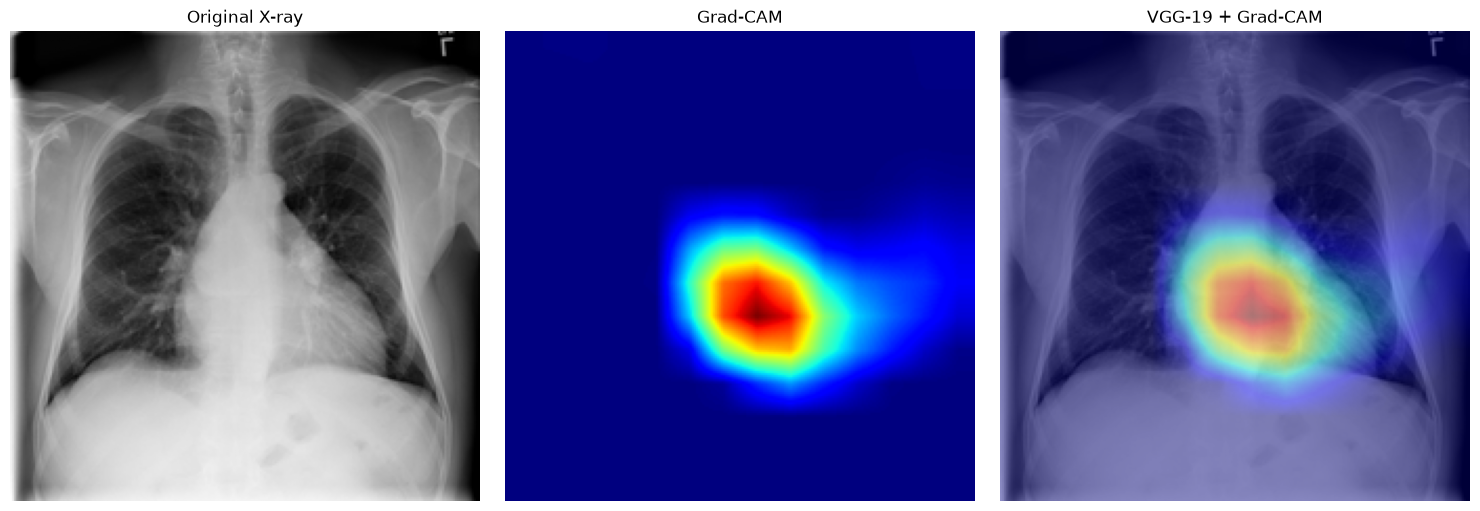


Grad-CAM generated successfully ✓
Finding     : Cardiomegaly
Probability : 0.8856
CAM shape   : (224, 224)


In [59]:
# ============================================================
# REAL VGG-19 GRAD-CAM — FIXED FOR IN-PLACE RELU
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

print("=" * 70)
print("REAL VGG-19 GRAD-CAM")
print("=" * 70)

# ------------------------------------------------------------
# Disable in-place ReLU operations
# ------------------------------------------------------------

for module in vgg19_model.modules():
    if isinstance(module, torch.nn.ReLU):
        module.inplace = False

print("In-place ReLU disabled for Grad-CAM ✓")

# ------------------------------------------------------------
# Target finding
# ------------------------------------------------------------

target_finding = "Cardiomegaly"
target_index = LABELS.index(target_finding)

print(f"Target finding : {target_finding}")
print(f"Target index   : {target_index}")
print(f"Probability    : {probabilities[target_index]:.4f}")

# ------------------------------------------------------------
# Prepare image
# ------------------------------------------------------------

vgg19_model.eval()

image = Image.open(image_path).convert("L")

input_tensor = (
    inference_transform(image)
    .unsqueeze(0)
    .to(DEVICE)
)

input_tensor.requires_grad_(True)

# ------------------------------------------------------------
# Storage for activations and gradients
# ------------------------------------------------------------

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

# Exact target layer used for VGG Grad-CAM
target_layer = vgg19_model.features[34]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------

vgg19_model.zero_grad(set_to_none=True)

logits = vgg19_model(input_tensor)

target_logit = logits[0, target_index]

print(f"Target logit  : {target_logit.item():.4f}")

# ------------------------------------------------------------
# Backward pass
# ------------------------------------------------------------

target_logit.backward()

# Remove hooks immediately
forward_handle.remove()
backward_handle.remove()

# ------------------------------------------------------------
# Verify captured tensors
# ------------------------------------------------------------

if activations is None or gradients is None:
    raise RuntimeError("Grad-CAM activations or gradients were not captured.")

print(f"Activation shape : {tuple(activations.shape)}")
print(f"Gradient shape   : {tuple(gradients.shape)}")

# ------------------------------------------------------------
# Grad-CAM
# ------------------------------------------------------------

activation = activations[0]
gradient = gradients[0]

# Average gradient over spatial dimensions
weights = gradient.mean(dim=(1, 2))

# Weighted combination of feature maps
cam = torch.sum(
    weights[:, None, None] * activation,
    dim=0
)

# Keep only positive influence
cam = torch.relu(cam)

# Convert to NumPy
cam = cam.detach().cpu().numpy()

# Normalize
if cam.max() > 0:
    cam = cam / cam.max()

# ------------------------------------------------------------
# Resize CAM to original image dimensions
# ------------------------------------------------------------

cam_tensor = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0)

cam_resized = F.interpolate(
    cam_tensor,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False
)

cam_resized = cam_resized.squeeze().numpy()

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

original_image = np.array(image)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap="gray")
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_resized, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(original_image, cmap="gray")
plt.imshow(cam_resized, cmap="jet", alpha=0.45)
plt.title("VGG-19 + Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()

print("\nGrad-CAM generated successfully ✓")
print(f"Finding     : {target_finding}")
print(f"Probability : {probabilities[target_index]:.4f}")
print(f"CAM shape   : {cam_resized.shape}")

In [60]:
# ============================================================
# REAL CNN → RAG → GEMINI INTEGRATION
# ============================================================

target_finding = "Cardiomegaly"
target_probability = float(probabilities[target_index])

gradcam_description = (
    "Grad-CAM highlights a region in the central thoracic/cardiac "
    "area that contributed to the Cardiomegaly prediction. "
    "The heatmap represents model attribution and should not be "
    "interpreted as direct anatomical or diagnostic evidence."
)

print("=" * 70)
print("REAL CNN → RAG → GEMINI")
print("=" * 70)

print(f"Finding     : {target_finding}")
print(f"Probability : {target_probability:.4f}")
print(f"Ground truth: Cardiomegaly")
print("\nSending real model output to the RAG + Gemini pipeline...")

real_ai_result = build_ai_result(
    finding=target_finding,
    probability=target_probability,
    gradcam_description=gradcam_description,
    top_k=5
)

print("\nPipeline completed ✓")

print("\n" + "=" * 70)
print("FINAL STRUCTURED RESULT")
print("=" * 70)

print("\nPrediction:")
print(real_ai_result["prediction"])

print("\nVisual Explanation:")
print(real_ai_result["visual_explanation"])

print("\nMedical Context:")
print(real_ai_result["medical_context"])

print("\nInterpretation:")
print(real_ai_result["interpretation"])

print("\nLimitations:")
for limitation in real_ai_result["limitations"]:
    print(f"- {limitation}")

print("\nCitations:")
for citation in real_ai_result["citations"]:
    print(f"- {citation}")

print("\nRAG:")
print(real_ai_result["rag"])

REAL CNN → RAG → GEMINI
Finding     : Cardiomegaly
Probability : 0.8856
Ground truth: Cardiomegaly

Sending real model output to the RAG + Gemini pipeline...


ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [61]:
# ============================================================
# REAL CNN → RAG EVIDENCE
# No Gemini API call
# ============================================================

print("=" * 70)
print("REAL CNN → RAG")
print("=" * 70)

real_finding = target_finding
real_probability = target_probability

# Retrieve evidence for the actual CNN prediction
real_rag_context = get_finding_rag_context(
    finding=real_finding,
    top_k=5
)

print(f"\nCNN finding       : {real_finding}")
print(f"CNN probability   : {real_probability:.4f}")
print(f"Evidence status   : {real_rag_context['evidence_status']}")

print("\n" + "-" * 70)
print("PRIMARY EVIDENCE")
print("-" * 70)

for item in real_rag_context["primary_evidence"]:
    print(
        f"\nRank  : {item['rank']}"
        f"\nScore : {item['score']:.4f}"
        f"\nID    : {item['chunk_id']}"
        f"\nTitle : {item['title']}"
    )

print("\n" + "-" * 70)
print("GENERAL EVIDENCE")
print("-" * 70)

for item in real_rag_context["general_evidence"]:
    print(
        f"\nRank  : {item['rank']}"
        f"\nScore : {item['score']:.4f}"
        f"\nID    : {item['chunk_id']}"
        f"\nTitle : {item['title']}"
    )

print("\n" + "=" * 70)
print("CNN → RAG CONNECTION VERIFIED ✓")
print("=" * 70)

REAL CNN → RAG

CNN finding       : Cardiomegaly
CNN probability   : 0.8856
Evidence status   : SUFFICIENT

----------------------------------------------------------------------
PRIMARY EVIDENCE
----------------------------------------------------------------------

Rank  : 1
Score : 0.6920
ID    : cardiomegaly_001
Title : Cardiomegaly

----------------------------------------------------------------------
GENERAL EVIDENCE
----------------------------------------------------------------------

Rank  : 2
Score : 0.6339
ID    : chest_xray_general_001
Title : Chest X-ray

Rank  : 3
Score : 0.5822
ID    : chest_xray_report_001
Title : How to Read Your Chest X-ray Report

Rank  : 5
Score : 0.4822
ID    : chestxray14_dataset_001
Title : ChestX-ray14 Dataset Context

CNN → RAG CONNECTION VERIFIED ✓


In [62]:
# ============================================================
# REAL RAG → GEMINI
# Uses the actual CNN prediction and Grad-CAM context
# ============================================================

print("=" * 70)
print("REAL RAG → GEMINI")
print("=" * 70)

print(f"Finding     : {real_finding}")
print(f"Probability : {real_probability:.4f}")
print(f"RAG status  : {real_rag_context['evidence_status']}")

try:
    gemini_result = generate_gemini_interpretation(
        finding=real_finding,
        probability=real_probability,
        gradcam_description=gradcam_description,
        top_k=5
    )

    print("\nGemini generation successful ✓")

    print("\n" + "-" * 70)
    print("GEMINI INTERPRETATION")
    print("-" * 70)

    gemini_response = gemini_result["gemini_response"]

    print("\nVisual Explanation:")
    print(gemini_response.visual_explanation.description)

    print("\nGrad-CAM Note:")
    print(gemini_response.visual_explanation.gradcam_note)

    print("\nMedical Context:")
    print(gemini_response.medical_context.summary)

    print("\nEvidence Status:")
    print(gemini_response.medical_context.evidence_status)

    print("\nInterpretation:")
    print(gemini_response.interpretation.summary)

    print("\nLimitations:")
    for limitation in gemini_response.limitations:
        print(f"- {limitation}")

    print("\nCitations:")
    for citation in gemini_response.citations:
        print(f"- {citation.chunk_id}: {citation.title}")

except Exception as e:
    print("\nGemini generation failed.")
    print(f"Error type : {type(e).__name__}")
    print(f"Error      : {e}")

REAL RAG → GEMINI
Finding     : Cardiomegaly
Probability : 0.8856
RAG status  : SUFFICIENT

Gemini generation successful ✓

----------------------------------------------------------------------
GEMINI INTERPRETATION
----------------------------------------------------------------------

Visual Explanation:
Grad-CAM highlights a region in the central thoracic/cardiac area that contributed to the Cardiomegaly prediction.

Grad-CAM Note:
The heatmap represents model attribution and should not be interpreted as direct anatomical or diagnostic evidence.

Medical Context:
Cardiomegaly is defined by an increased cardiothoracic ratio, typically greater than or equal to 50% of the transverse diameter of the chest on a chest radiograph.

Evidence Status:
SUFFICIENT

Interpretation:
The model identified features consistent with cardiomegaly. Clinical assessment may require echocardiography to evaluate cardiac chamber size and function.

Limitations:
- Apparent cardiac size on X-ray can be affect

In [63]:
# ============================================================
# VALIDATE REAL GEMINI RESPONSE AGAINST REAL RAG EVIDENCE
# ============================================================

print("=" * 70)
print("REAL GEMINI CITATION VALIDATION")
print("=" * 70)

# Convert Pydantic response to a normal dictionary
if hasattr(gemini_response, "model_dump"):
    gemini_dict = gemini_response.model_dump()
else:
    gemini_dict = gemini_response

validation_result = validate_grounding(
    response=gemini_dict,
    rag_context=real_rag_context
)

print("\nValidation status:")
print(f"VALID : {validation_result['valid']}")

print("\nErrors:")
if validation_result["errors"]:
    for error in validation_result["errors"]:
        print(f"- {error}")
else:
    print("- None")

print("\nWarnings:")
for warning in validation_result["warnings"]:
    print(f"- {warning}")

print("\n" + "=" * 70)

if validation_result["valid"]:
    print("REAL GEMINI RESPONSE PASSED CITATION REFERENCE CHECK ✓")
else:
    print("CITATION VALIDATION FAILED — REVIEW REQUIRED")

print("=" * 70)

REAL GEMINI CITATION VALIDATION

Validation status:
VALID : True

Errors:
- None

Warnings:
- Citation validation confirms evidence references, but does not prove every generated statement is supported.

REAL GEMINI RESPONSE PASSED CITATION REFERENCE CHECK ✓


In [64]:
# ============================================================
# FINAL END-TO-END INFERENCE FUNCTION
# VGG-19 → Grad-CAM → RAG → Gemini
# ============================================================

def run_full_inference(
    image_path,
    top_k_rag=5
):
    """
    Complete inference pipeline for one chest X-ray.

    Pipeline:
        Image
          ↓
        VGG-19
          ↓
        14 probabilities
          ↓
        Top finding
          ↓
        Grad-CAM
          ↓
        RAG retrieval
          ↓
        Gemini interpretation
          ↓
        Citation validation

    Returns:
        A single structured dictionary suitable for Streamlit.
    """

    # --------------------------------------------------------
    # 1. Load image
    # --------------------------------------------------------

    image = Image.open(image_path).convert("L")

    input_tensor = (
        inference_transform(image)
        .unsqueeze(0)
        .to(DEVICE)
    )

    # --------------------------------------------------------
    # 2. VGG-19 prediction
    # --------------------------------------------------------

    vgg19_model.eval()

    with torch.inference_mode():
        logits = vgg19_model(input_tensor)
        probabilities_tensor = torch.sigmoid(logits)[0]

    probabilities = probabilities_tensor.cpu().numpy()

    # All 14 predictions
    predictions = {
        label: float(probability)
        for label, probability in zip(LABELS, probabilities)
    }

    # Top prediction
    top_index = int(np.argmax(probabilities))

    finding = LABELS[top_index]
    probability = float(probabilities[top_index])

    # --------------------------------------------------------
    # 3. Grad-CAM
    # --------------------------------------------------------

    # Grad-CAM requires gradients, so create a fresh tensor
    gradcam_input = (
        inference_transform(image)
        .unsqueeze(0)
        .to(DEVICE)
    )

    gradcam_input.requires_grad_(True)

    activations = None
    gradients = None

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output

    def backward_hook(module, grad_input, grad_output):
        nonlocal gradients
        gradients = grad_output[0]

    target_layer = vgg19_model.features[34]

    forward_handle = target_layer.register_forward_hook(
        forward_hook
    )

    backward_handle = target_layer.register_full_backward_hook(
        backward_hook
    )

    vgg19_model.zero_grad(set_to_none=True)

    gradcam_logits = vgg19_model(gradcam_input)

    target_logit = gradcam_logits[0, top_index]

    target_logit.backward()

    forward_handle.remove()
    backward_handle.remove()

    activation = activations[0]
    gradient = gradients[0]

    weights = gradient.mean(dim=(1, 2))

    cam = torch.sum(
        weights[:, None, None] * activation,
        dim=0
    )

    cam = torch.relu(cam)

    cam = cam.detach().cpu().numpy()

    if cam.max() > 0:
        cam = cam / cam.max()

    cam_tensor = (
        torch.from_numpy(cam)
        .unsqueeze(0)
        .unsqueeze(0)
    )

    cam_resized = F.interpolate(
        cam_tensor,
        size=image.size[::-1],
        mode="bilinear",
        align_corners=False
    )

    cam_resized = cam_resized.squeeze().numpy()

    # --------------------------------------------------------
    # 4. Grad-CAM description
    # --------------------------------------------------------

    gradcam_description = (
        f"Grad-CAM highlights image regions that contributed "
        f"to the {finding} prediction. The heatmap represents "
        f"model attribution and should not be interpreted as "
        f"direct anatomical or diagnostic evidence."
    )

    # --------------------------------------------------------
    # 5. RAG retrieval
    # --------------------------------------------------------

    rag_context = get_finding_rag_context(
        finding=finding,
        top_k=top_k_rag
    )

    # --------------------------------------------------------
    # 6. Gemini interpretation
    # --------------------------------------------------------

    gemini_result = generate_gemini_interpretation(
        finding=finding,
        probability=probability,
        gradcam_description=gradcam_description,
        top_k=top_k_rag
    )

    gemini_response = gemini_result["gemini_response"]

    # --------------------------------------------------------
    # 7. Convert Gemini response to dictionary
    # --------------------------------------------------------

    if hasattr(gemini_response, "model_dump"):
        gemini_dict = gemini_response.model_dump()
    else:
        gemini_dict = gemini_response

    # --------------------------------------------------------
    # 8. Citation validation
    # --------------------------------------------------------

    citation_validation = validate_grounding(
        response=gemini_dict,
        rag_context=rag_context
    )

    # --------------------------------------------------------
    # 9. Final structured result
    # --------------------------------------------------------

    result = {
        "image": {
            "path": str(image_path),
            "width": image.width,
            "height": image.height
        },

        "predictions": predictions,

        "top_prediction": {
            "finding": finding,
            "probability": probability
        },

        "gradcam": {
            "target_layer": "features[34]",
            "heatmap": cam_resized,
            "description": gradcam_description
        },

        "rag": {
            "query": rag_context["query"],
            "evidence_status": rag_context["evidence_status"],
            "primary_evidence": rag_context["primary_evidence"],
            "general_evidence": rag_context["general_evidence"]
        },

        "llm": gemini_dict,

        "citation_validation": citation_validation
    }

    return result


print("=" * 70)
print("FINAL INFERENCE FUNCTION CREATED ✓")
print("=" * 70)

print("\nPipeline:")
print("Image → VGG-19 → Grad-CAM → RAG → Gemini → Validation")

print("\nReturn object:")
print("result = run_full_inference(image_path)")

FINAL INFERENCE FUNCTION CREATED ✓

Pipeline:
Image → VGG-19 → Grad-CAM → RAG → Gemini → Validation

Return object:
result = run_full_inference(image_path)


In [65]:
# ============================================================
# FULL END-TO-END PIPELINE TEST
# ============================================================

print("=" * 70)
print("FULL END-TO-END INFERENCE TEST")
print("=" * 70)

result = run_full_inference(
    image_path=image_path,
    top_k_rag=5
)

print("\nPipeline completed successfully ✓")

print("\n" + "-" * 70)
print("PREDICTION")
print("-" * 70)

print(
    f"Finding     : {result['top_prediction']['finding']}"
)

print(
    f"Probability : "
    f"{result['top_prediction']['probability']:.4f}"
)

print("\n" + "-" * 70)
print("RAG")
print("-" * 70)

print(
    f"Evidence status : "
    f"{result['rag']['evidence_status']}"
)

print(
    f"Primary chunks  : "
    f"{len(result['rag']['primary_evidence'])}"
)

print(
    f"General chunks  : "
    f"{len(result['rag']['general_evidence'])}"
)

print("\n" + "-" * 70)
print("LLM")
print("-" * 70)

print(
    "Interpretation:"
)

print(
    result["llm"]["interpretation"]["summary"]
)

print("\n" + "-" * 70)
print("CITATION VALIDATION")
print("-" * 70)

print(
    f"Valid : "
    f"{result['citation_validation']['valid']}"
)

print(
    f"Errors: "
    f"{len(result['citation_validation']['errors'])}"
)

print("\n" + "=" * 70)
print("FULL PIPELINE TEST COMPLETE ✓")
print("=" * 70)

FULL END-TO-END INFERENCE TEST

Pipeline completed successfully ✓

----------------------------------------------------------------------
PREDICTION
----------------------------------------------------------------------
Finding     : Cardiomegaly
Probability : 0.8856

----------------------------------------------------------------------
RAG
----------------------------------------------------------------------
Evidence status : SUFFICIENT
Primary chunks  : 1
General chunks  : 3

----------------------------------------------------------------------
LLM
----------------------------------------------------------------------
Interpretation:
The model has identified features associated with cardiomegaly. Clinical assessment, such as echocardiography, may be required to evaluate cardiac chamber size and function.

----------------------------------------------------------------------
CITATION VALIDATION
----------------------------------------------------------------------
Valid : True
Err

In [66]:
# ============================================================
# FOLLOW-UP MEDICAL Q&A
# Finding-aware RAG → Gemini
# ============================================================

def answer_followup_question(
    question,
    finding,
    top_k=5
):
    """
    Answer a user follow-up question using the detected finding
    and the existing V2 RAG corpus.

    The CNN prediction is never modified by this function.
    """

    # --------------------------------------------------------
    # 1. Build question-aware retrieval query
    # --------------------------------------------------------

    retrieval_query = (
        f"Regarding {finding}: {question}"
    )

    # --------------------------------------------------------
    # 2. Retrieve relevant evidence
    # --------------------------------------------------------

    retrieved = retrieve_v2(
        retrieval_query,
        top_k=top_k
    )

    # --------------------------------------------------------
    # 3. Separate finding-specific and general evidence
    # --------------------------------------------------------

    primary_evidence = []
    general_evidence = []

    for item in retrieved:

        if item["finding"] == finding:
            primary_evidence.append(item)

        elif item["finding"] == "General":
            general_evidence.append(item)

    # --------------------------------------------------------
    # 4. Build evidence text
    # --------------------------------------------------------

    evidence_blocks = []

    for item in retrieved:
        evidence_blocks.append(
            f"""
CHUNK ID: {item['chunk_id']}
TITLE: {item['title']}
FINDING: {item['finding']}
CONTENT:
{item['text']}
"""
        )

    evidence_text = "\n".join(evidence_blocks)

    # --------------------------------------------------------
    # 5. Build Gemini prompt
    # --------------------------------------------------------

    prompt = f"""
You are an evidence-grounded medical information assistant
supporting an academic chest X-ray AI system.

Detected finding from the CNN:
{finding}

User question:
{question}

Retrieved evidence:
{evidence_text}

Instructions:

1. Answer the user's question using the retrieved evidence.
2. Do not change, reinterpret, or override the CNN prediction.
3. Do not invent medical facts that are not supported by the
   retrieved evidence.
4. If the retrieved evidence does not answer the question,
   explicitly say that the available evidence is insufficient.
5. Do not provide a personalized diagnosis or personalized
   treatment plan.
6. For medication, treatment, prognosis, or recovery-time
   questions, do not invent specific recommendations or
   timelines.
7. Return the chunk IDs used to support the answer.
8. Keep the answer concise and understandable.

Return JSON in exactly this structure:

{{
    "answer": "Your answer here",
    "citations": [
        {{
            "chunk_id": "chunk_id_here",
            "title": "source title here"
        }}
    ]
}}
"""

    # --------------------------------------------------------
    # 6. Gemini generation
    # --------------------------------------------------------

    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt,
        config=gemini_config
    )

    # --------------------------------------------------------
    # 7. Parse JSON
    # --------------------------------------------------------

    raw_text = response.text.strip()

    if raw_text.startswith("```"):
        raw_text = raw_text.replace("```json", "")
        raw_text = raw_text.replace("```", "")
        raw_text = raw_text.strip()

    qa_response = json.loads(raw_text)

    # --------------------------------------------------------
    # 8. Validate citation references
    # --------------------------------------------------------

    rag_context = {
        "query": retrieval_query,
        "primary_evidence": primary_evidence,
        "general_evidence": general_evidence,
        "evidence_status": (
            "SUFFICIENT"
            if primary_evidence
            else "LIMITED"
            if general_evidence
            else "INSUFFICIENT"
        )
    }

    validation = validate_grounding(
        response=qa_response,
        rag_context=rag_context
    )

    # --------------------------------------------------------
    # 9. Final result
    # --------------------------------------------------------

    return {
        "question": question,
        "finding": finding,
        "answer": qa_response["answer"],
        "citations": qa_response.get("citations", []),
        "rag": {
            "query": retrieval_query,
            "evidence_status": rag_context["evidence_status"],
            "retrieved_chunks": [
                {
                    "chunk_id": item["chunk_id"],
                    "title": item["title"],
                    "score": item["score"]
                }
                for item in retrieved
            ]
        },
        "citation_validation": validation
    }


print("=" * 70)
print("FOLLOW-UP Q&A FUNCTION CREATED ✓")
print("=" * 70)

print("\nUsage:")
print("""
qa_result = answer_followup_question(
    question="What is cardiomegaly?",
    finding="Cardiomegaly"
)
""")

FOLLOW-UP Q&A FUNCTION CREATED ✓

Usage:

qa_result = answer_followup_question(
    question="What is cardiomegaly?",
    finding="Cardiomegaly"
)



In [67]:
# ============================================================
# FOLLOW-UP Q&A TEST
# ============================================================

print("=" * 70)
print("FOLLOW-UP Q&A TEST")
print("=" * 70)

qa_result = answer_followup_question(
    question="What is cardiomegaly?",
    finding="Cardiomegaly"
)

print("\nQuestion:")
print(qa_result["question"])

print("\nAnswer:")
print(qa_result["answer"])

print("\nCitations:")
for citation in qa_result["citations"]:
    print(
        f"- {citation['chunk_id']}: "
        f"{citation['title']}"
    )

print("\nRAG Evidence Status:")
print(
    qa_result["rag"]["evidence_status"]
)

print("\nCitation Validation:")
print(
    f"Valid: "
    f"{qa_result['citation_validation']['valid']}"
)

print("\n" + "=" * 70)
print("FOLLOW-UP Q&A TEST COMPLETE ✓")
print("=" * 70)

FOLLOW-UP Q&A TEST

Question:
What is cardiomegaly?

Answer:
Cardiomegaly refers to an increased size of the heart. On a chest X-ray, it is clinically defined by a cardiothoracic ratio—the transverse diameter of the cardiac silhouette compared to the transverse diameter of the chest—that is greater than or equal to 50%. While a chest X-ray can suggest cardiomegaly and provide clues about specific chamber enlargement, the apparent size can be influenced by imaging technique and projection. Further evaluation, such as an echocardiogram, may be required to assess heart function and determine the underlying cause.

Citations:
- cardiomegaly_001: Cardiomegaly

RAG Evidence Status:
SUFFICIENT

Citation Validation:
Valid: True

FOLLOW-UP Q&A TEST COMPLETE ✓


In [68]:
# ============================================================
# DIRECT GEMINI FOLLOW-UP Q&A
# No RAG retrieval
# ============================================================

def ask_gemini_followup(
    question,
    finding,
    probability,
    initial_interpretation
):
    """
    Answer a follow-up user question directly with Gemini.

    RAG is used only during the initial X-ray analysis.
    """

    prompt = f"""
You are the conversational medical-information assistant
for an academic chest X-ray AI system.

The system's initial image analysis identified:

Finding:
{finding}

CNN probability:
{probability:.4f}

Initial AI interpretation:
{initial_interpretation}

The user is now asking a follow-up question:

{question}

Instructions:

1. Answer the user's question directly and clearly.
2. Use the initial X-ray result only as context.
3. Do not change, override, or reinterpret the CNN prediction.
4. This is general medical information, not a personalized
   diagnosis or treatment plan.
5. If the user asks about medications, treatment, prognosis,
   recovery time, or other medical decisions, explain the
   relevant general information without pretending to know
   the user's individual clinical situation.
6. Do not invent a precise recovery timeline when one cannot
   be determined from the available information.
7. Do not claim that the X-ray alone establishes a diagnosis.
8. Keep the answer understandable and reasonably concise.

Return only the answer text.
"""

    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt,
        config=gemini_config
    )

    return {
        "question": question,
        "finding": finding,
        "probability": float(probability),
        "answer": response.text.strip()
    }


print("=" * 70)
print("DIRECT GEMINI FOLLOW-UP FUNCTION CREATED ✓")
print("=" * 70)

print("\nRAG usage:")
print("Initial X-ray analysis → YES")
print("Follow-up questions  → NO")

DIRECT GEMINI FOLLOW-UP FUNCTION CREATED ✓

RAG usage:
Initial X-ray analysis → YES
Follow-up questions  → NO


In [69]:
# ============================================================
# DIRECT GEMINI FOLLOW-UP TEST
# ============================================================

print("=" * 70)
print("DIRECT GEMINI FOLLOW-UP TEST")
print("=" * 70)

followup_result = ask_gemini_followup(
    question=(
        "What medications are generally used to manage "
        "conditions that can cause cardiomegaly?"
    ),
    finding=result["top_prediction"]["finding"],
    probability=result["top_prediction"]["probability"],
    initial_interpretation=result["llm"]["interpretation"]["summary"]
)

print("\nQuestion:")
print(followup_result["question"])

print("\nDetected finding:")
print(followup_result["finding"])

print("\nCNN probability:")
print(f"{followup_result['probability']:.4f}")

print("\nGemini answer:")
print("-" * 70)
print(followup_result["answer"])

print("\n" + "=" * 70)
print("DIRECT GEMINI FOLLOW-UP TEST COMPLETE ✓")
print("=" * 70)

DIRECT GEMINI FOLLOW-UP TEST

Question:
What medications are generally used to manage conditions that can cause cardiomegaly?

Detected finding:
Cardiomegaly

CNN probability:
0.8856

Gemini answer:
----------------------------------------------------------------------
Cardiomegaly, or an enlarged heart, is a clinical finding rather than a specific disease; it is often a sign of an underlying condition such as hypertension, heart valve disease, or cardiomyopathy. Because the causes vary, the medications used to manage these conditions depend entirely on the specific diagnosis determined by a physician.

Common classes of medications used to manage conditions associated with cardiomegaly include:

*   **ACE Inhibitors or ARBs:** Often prescribed to lower blood pressure and reduce the workload on the heart.
*   **Beta-blockers:** Used to slow the heart rate and lower blood pressure, which can help improve heart function over time.
*   **Diuretics:** These help the body eliminate excess f